In [ ]:
#| default_exp shapelets_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Shapelets

::: {.callout-note title="Shapelets"}
Shapelets provide a way to test whether time‑series classes differ through localized, discriminative subsequences. By searching for short patterns whose presence or absence separates classes, the method exposes whether class identity is tied to specific temporal motifs. When shapelets achieve high accuracy and remain stable across training runs, they indicate that classes share consistent, characteristic subsequences; when no such motifs emerge, the learned shapelets become diffuse, redundant, or weakly informative, suggesting limited or noisy class structure.
:::

## Import Data
> to skip the first three steps of the [basic workflow](./module_functions_ex.ipynb#obtain_input_data): Obtain, Prepare, Split and Scale

In [ ]:
#| eval: false

from nbdev_fhemb.module_functions_ex import X_train, X_test, y_train, y_test

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

## Train and Test

### Shapelet embedding
> `calc_shapelet` trains the shapelet model using (`X_train`, `y_train`) and then applies the learned shapelet transform to both `X_train` and `X_test`, returning the resulting shapelet embeddings.

In [ ]:
#| eval: false
from fhemb.utils.cutils import calc_shapelet

In [ ]:
#| eval: false
X_train_transformed, X_test_transformed=calc_shapelet( 
    X_train.squeeze(),   # squeeze to remove singleton dimension: (44, 250, 1) -> (44, 250) where 250 is the number of timesteps
    X_test.squeeze(),    # 
    y_train              # train labels that serve to optimize the shapelets for distinguishing classes
)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/tslearn/shapelets/shapelets.py:354: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

::: {.callout-note title="Shapelet embedding"}
The shapelet transform converts each time series into a vector of distances to a learned set of shapelets. These distances quantify how strongly each discriminative pattern is expressed in the input, yielding a representation that emphasizes classrelevant structure. The resulting features can be passed to any downstream classifier, providing a compact and informative basis for accurate time‑series classification.
:::


### Calculate accuracies
>1. Fit classifiers on the shapelet‑transformed training data.
>2. Use the fitted classifiers to predict labels for the shapelet‑transformed test data.
>3. Compare the predicted labels with the true test labels to compute accuracy scores.

In [ ]:
#| eval: false
from fhemb.utils.cutils import calc_accuracies

In [ ]:
#| eval: false

calc_accuracies(
    X_train_transformed,  # train data embedded via shapelets
    X_test_transformed,   # test data embedded via shapelets
    y_train,              # train labels
    y_test                # test labels   
)

 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.50
 [WARNING] cutils.calc_accuracies: Error with kernel precomputed: Precomputed matrix must be a square matrix. Input is a 44x3 matrix.
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 [INFO] cutils.calc_accuracies: Accuracy of rotf: 0.40
 [WARNING] cutils

{'randf': 0.6,
 'svm_rbf': 0.5,
 'svm_sigmoid': 0.6,
 'svm_poly': 0.5,
 'svm_linear': 0.5,
 'rotf': 0.4,
 'knn_euclidean': 0.6,
 'knn_cosine': 0.45,
 'knn_nan_euclidean': 0.6,
 'knn_l1': 0.55,
 'knn_minkowski': 0.6}

## Diagnose via a Pairwise Relation and Dimensionality Reduction

### Projection of the input space into a low-dimensional space

#### UMAP projection

In [ ]:
#| eval: false

from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.decomposition import PCA

In [ ]:
#| eval: false

umap=UMAP(n_components=3, random_state=0)
reduced_umap=umap.fit_transform(X_test_transformed)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
#| echo: false

import matplotlib.pyplot as plt

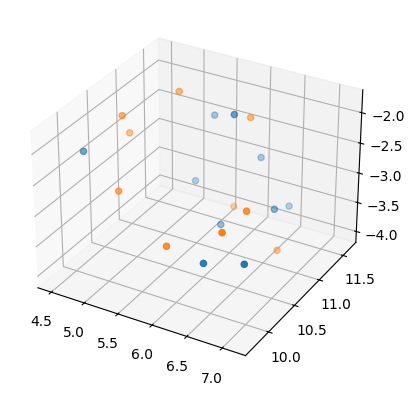

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced_umap[y_test==0, 0], reduced_umap[y_test==0, 1], reduced_umap[y_test==0, 2])
ax.scatter(reduced_umap[y_test==1, 0], reduced_umap[y_test==1, 1], reduced_umap[y_test==1, 2])
plt.show()

#### PCA projection

In [ ]:
#| eval: false

pca=PCA(n_components=3, random_state=0)
reduced_pca=pca.fit_transform(X_test_transformed)

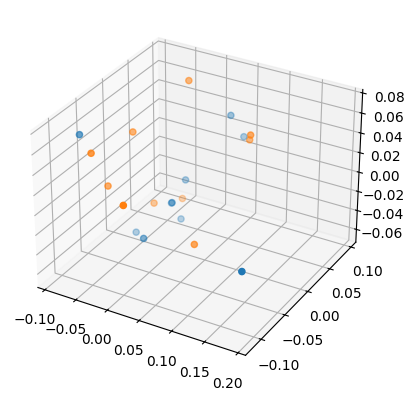

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced_pca[y_test==0, 0], reduced_pca[y_test==0, 1], reduced_pca[y_test==0, 2])
ax.scatter(reduced_pca[y_test==1, 0], reduced_pca[y_test==1, 1], reduced_pca[y_test==1, 2])
plt.show()

### Projection of a pairwise relation embedding of the input space into a low-dimensional space

In [ ]:
#| eval: false

from fhemb.utils.cutils import plot_pr_projection

 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 210/210 [00:26<00:00,  8.00it/s]
 [WARNING] cutils.plot_pr_projection: PCA on distance-correlation matrices behaves like kernel PCA. Consider MDS or TSNE for distance-based projections.


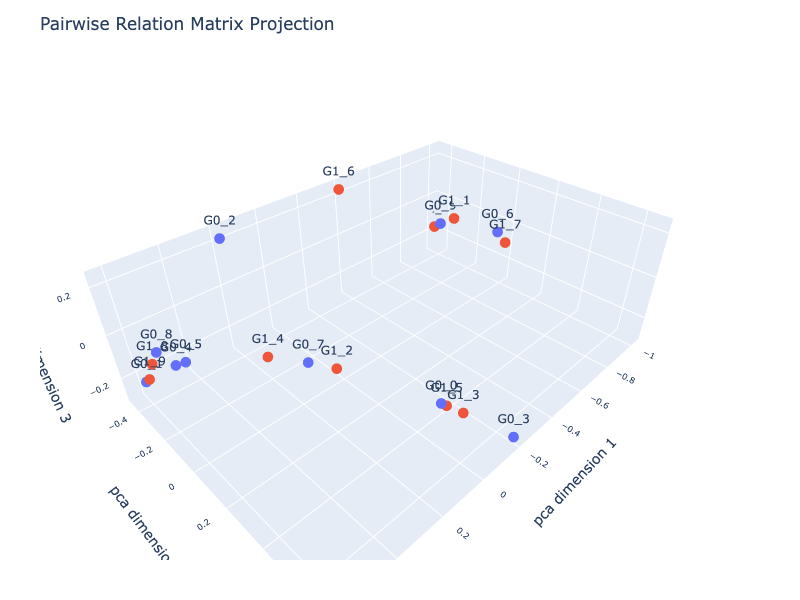

In [ ]:
#| eval: false

plot_pr_projection(
    X_test_transformed[y_test==0],
    X_test_transformed[y_test==1],   # data matrices for two groups 
    alignment_type='dcor',           # distance correlation by Székely, Rizzo, and Bakirov (2007)            
    projection='pca',                # projection method for dimensionality reduction ('pca', 'tsne', 'mds', 'umap') 
    transformation='minmax',         # to transform distances into similarities for PCA
    normalize='l1',                  # normalization method for distance matrix
    n_jobs=8,                        # number of jobs for parallelization
    dimensions=3,                    # number of dimensions of the projection
)